# Implementacja BRNN w TensorFlow

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, SimpleRNN, Dense

inputs = Input(shape=(10, 50))  # sequence_length=10, input_dim=50
x = Bidirectional(SimpleRNN(64))(inputs)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy')
model.summary()

# Przykładowe dane wejściowe:
import numpy as np
x_sample = np.random.rand(32, 10, 50).astype(np.float32)  # batch_size=32
out = model(x_sample)
print(out.shape)  # (32, 1)

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,849 (58.00 KB)

 Non-trainable params: 0 (0.00 B)

(32, 1)


In [13]:
!pip install tatoebatools
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, SimpleRNN, Dense, Dropout
import matplotlib.pyplot as plt
from tatoebatools import tatoeba

Pobieranie i łączenie danych z Tatoeba
Stworzono Tatoeba Mini-Corpus. Łączna liczba zdań: 3000


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 15, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,899 (1.29 MB)

 Trainable params: 336,899 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7958 - loss: 0.4744 - val_accuracy: 0.9767 - val_loss: 0.0816
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9887 - loss: 0.0400 - val_accuracy: 0.9900 - val_loss: 0.0557
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9987 - loss: 0.0084 - val_accuracy: 0.9867 - val_loss: 0.0607
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.9900 - val_loss: 0.0664
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9971 - loss: 0.0147 - val_accuracy: 0.9883 - val_loss: 0.0472
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9975 - loss: 0.0146 - val_accuracy: 0.9850 - val_loss: 0.0583
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9983 - loss: 0.0086 - val_accuracy: 0.9883 - val_loss: 0.0488
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9850 - val_loss

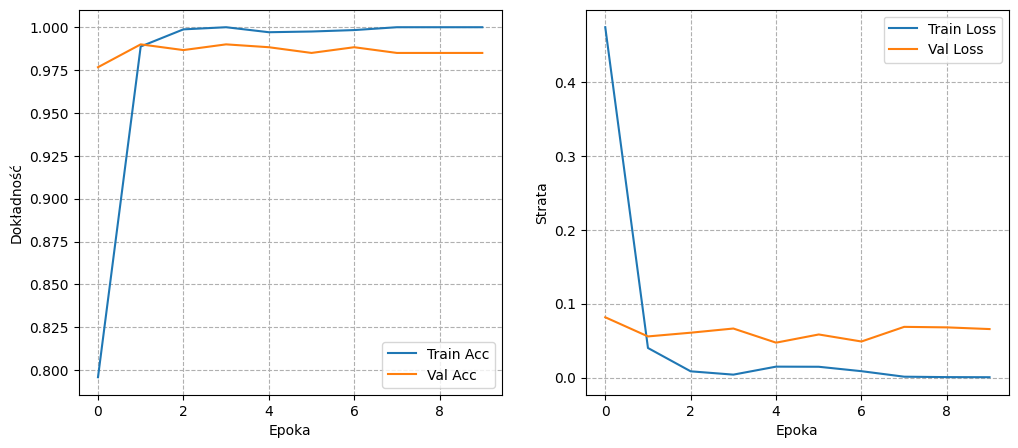

In [20]:
# POBRANIE DANYCH
print("Pobieranie i łączenie danych z Tatoeba")

df_eng = tatoeba.get("sentences_detailed", ["eng"])
df_fra = tatoeba.get("sentences_detailed", ["fra"])
df_deu = tatoeba.get("sentences_detailed", ["deu"])

df_eng['label'] = 0
df_fra['label'] = 1
df_deu['label'] = 2

df_eng = df_eng[['text', 'label']]
df_fra = df_fra[['text', 'label']]
df_deu = df_deu[['text', 'label']]

MAX_ROWS = 1000
df_all = pd.concat([
    df_eng.head(MAX_ROWS),
    df_fra.head(MAX_ROWS),
    df_deu.head(MAX_ROWS)
], ignore_index=True)

df_all = df_all.dropna()
df_all['text'] = df_all['text'].astype(str)

sentences = df_all['text'].values
labels = df_all['label'].values

print(f"Stworzono Tatoeba Mini-Corpus. Łączna liczba zdań: {len(sentences)}")


# PRZYGOTOWANIE DANYCH - TOKENIZACJA

vocab_size = 5000
max_sequence_length = 15

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=vocab_size, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)
X_data = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post')
Y_data = np.array(labels, dtype=np.int32)

indices = np.arange(X_data.shape[0])
np.random.shuffle(indices)
X_data, Y_data = X_data[indices], Y_data[indices]

split_idx = int(0.8 * len(X_data))
X_train, X_val = X_data[:split_idx], X_data[split_idx:]
Y_train, Y_val = Y_data[:split_idx], Y_data[split_idx:]


# BRNN

inputs = Input(shape=(max_sequence_length,))
x = Embedding(input_dim=vocab_size, output_dim=64)(inputs)
x = Dropout(0.3)(x)

x = Bidirectional(SimpleRNN(64))(x)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()


history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, Y_val)
)


# TEST NA ZDANIU

test_sentence = ["wie geht es"]
test_seq = tokenizer.texts_to_sequences(test_sentence)
test_padded = tf.keras.preprocessing.sequence.pad_sequences(test_seq, maxlen=max_sequence_length, padding='post')

predictions = model.predict(test_padded)
predicted_class = np.argmax(predictions)

languages = {0: "Angielski (EN)", 1: "Francuski (FR)", 2: "Niemiecki (DE)"}


print(f"WYNIK TESTU DLA ZDANIA: {test_sentence}")
print(f"Prawdopodobieństwa: EN: {predictions[0][0]:.4f}, FR: {predictions[0][1]:.4f}, DE: {predictions[0][2]:.4f}")
print(f"Rozpoznany język przez BRNN: {languages[predicted_class]}")


#
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()